In [1]:
%load_ext autoreload
%autoreload 2
import os

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print(os.getcwd()) # should end in /medjudge-audit

/Users/berniceyan/medjudge-audit


In [2]:
import numpy as np
import pandas as pd
from judgeaudit.agreement import safe_kappa
from judgeaudit.uncertainty import cluster_bootstrap, naive_bootstrap

In [5]:
raw = pd.read_json("results/grades_track_a.jsonl", lines=True)
v1 = raw[(raw.variant == "v1_official") & raw.grade.notna()].copy()

v1["grade_b"] = v1.grade.astype(bool)
v1["family"] = (v1.theme.str.removeprefix("cluster:")
                  .str.extract(r"^(communication|complex_responses|context_seeking|"
                               r"health_data_tasks|hedging|emergency_referrals|"
                               r"global_health)")[0].fillna("other"))

wide = v1.pivot_table(index="item_id", columns="judge_model",
                      values="grade_b", aggfunc="first")
wide.columns = ["sonnet", "flash", "gpt41"]     # alphabetical: anthropic, google, openai
meta = (v1.drop_duplicates("item_id").set_index("item_id")
          [["prompt_id", "physician_label", "family", "physician_agreement"]])
items = wide.join(meta).reset_index()

# complete cases only: fair comparisons require the same items for every judge
n_before = len(items)
items = items.dropna(subset=["sonnet", "flash", "gpt41"])
print(f"dropped {n_before - len(items)} items lacking a verdict from any judge")
items["majority"] = items[["sonnet", "flash", "gpt41"]].mean(axis=1) > 0.5
items[["sonnet","flash","gpt41","majority"]] = items[["sonnet","flash","gpt41","majority"]].astype(bool)

dropped 13 items lacking a verdict from any judge


In [6]:
JUDGES = ["gpt41", "flash", "sonnet"]

def kappa_of(d, col):
    return safe_kappa(d.physician_label.to_numpy(), d[col].to_numpy())

for j in JUDGES:
    pt, lo, hi = cluster_bootstrap(items, lambda d, j=j: kappa_of(d, j))
    print(f"{j:8s} κ = {pt:.3f}  [{lo:.3f}, {hi:.3f}]")

gpt41    κ = 0.595  [0.536, 0.650]
flash    κ = 0.490  [0.428, 0.551]
sonnet   κ = 0.403  [0.353, 0.450]


In [7]:
from itertools import combinations

for a, b in combinations(JUDGES, 2):
    pt, lo, hi = cluster_bootstrap(
        items, lambda d, a=a, b=b: kappa_of(d, a) - kappa_of(d, b))
    verdict = "EXCLUDES 0 — real difference" if (lo > 0 or hi < 0) else "includes 0 — not established"
    print(f"κ({a}) − κ({b}) = {pt:+.3f}  [{lo:+.3f}, {hi:+.3f}]  {verdict}")

κ(gpt41) − κ(flash) = +0.105  [+0.040, +0.168]  EXCLUDES 0 — real difference
κ(gpt41) − κ(sonnet) = +0.192  [+0.141, +0.240]  EXCLUDES 0 — real difference
κ(flash) − κ(sonnet) = +0.087  [+0.021, +0.153]  EXCLUDES 0 — real difference


In [8]:
pt, lo, hi = cluster_bootstrap(
    items, lambda d: kappa_of(d, "majority") - kappa_of(d, "gpt41"))
print(f"κ(majority) − κ(gpt-4.1) = {pt:+.3f}  [{lo:+.3f}, {hi:+.3f}]")

κ(majority) − κ(gpt-4.1) = -0.009  [-0.033, +0.016]


In [9]:
def dead_zone_gap(d, col="gpt41"):
    dz   = d[d.family == "complex_responses"]
    rest = d[d.family != "complex_responses"]
    return kappa_of(rest, col) - kappa_of(dz, col)

for j in JUDGES:
    pt, lo, hi = cluster_bootstrap(items, lambda d, j=j: dead_zone_gap(d, j))
    print(f"{j}: κ(elsewhere) − κ(complex_responses) = {pt:+.3f}  [{lo:+.3f}, {hi:+.3f}]")

gpt41: κ(elsewhere) − κ(complex_responses) = +0.463  [+0.201, +0.699]
flash: κ(elsewhere) − κ(complex_responses) = +0.428  [+0.180, +0.622]
sonnet: κ(elsewhere) − κ(complex_responses) = +0.350  [+0.238, +0.455]


In [10]:
stat = lambda d: kappa_of(d, "gpt41")
c_pt, c_lo, c_hi = cluster_bootstrap(items, stat)
n_pt, n_lo, n_hi = naive_bootstrap(items, stat)
print(f"clustered: [{c_lo:.3f}, {c_hi:.3f}]  width {c_hi - c_lo:.3f}")
print(f"naive:     [{n_lo:.3f}, {n_hi:.3f}]  width {n_hi - n_lo:.3f}")
print(f"naive understates uncertainty by {(c_hi - c_lo) / (n_hi - n_lo):.2f}x")

clustered: [0.536, 0.650]  width 0.114
naive:     [0.539, 0.650]  width 0.111
naive understates uncertainty by 1.03x


In [12]:
items.groupby("prompt_id").size().describe()

count    1284.000000
mean        1.235202
std         0.501726
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
dtype: float64

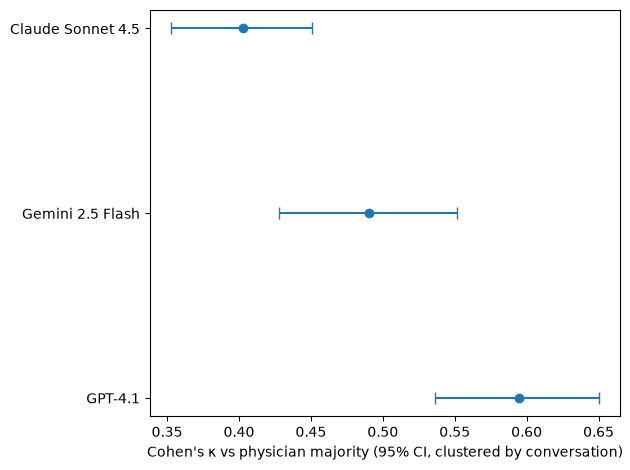

In [13]:
import matplotlib.pyplot as plt

res = {j: cluster_bootstrap(items, lambda d, j=j: kappa_of(d, j)) for j in JUDGES}
labels = {"gpt41": "GPT-4.1", "flash": "Gemini 2.5 Flash", "sonnet": "Claude Sonnet 4.5"}
ys = range(len(JUDGES))
pts  = [res[j][0] for j in JUDGES]
errs = [[res[j][0] - res[j][1] for j in JUDGES],
        [res[j][2] - res[j][0] for j in JUDGES]]
plt.errorbar(pts, ys, xerr=errs, fmt="o", capsize=4)
plt.yticks(ys, [labels[j] for j in JUDGES])
plt.xlabel("Cohen's κ vs physician majority (95% CI, clustered by conversation)")
plt.tight_layout()
plt.savefig("results/fig_judge_kappa_ci.png", dpi=200, bbox_inches="tight")